# Notebook for preprocessing CAMS fluxes for CIF-FLEXPART CO2 runs

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import os
import dask
from dask.distributed import Client
from global_land_mask import globe

In [2]:
def select_area(aoi, ds):
    # Determine the dimension names for latitude and longitude
    lat_name = 'lat' if 'lat' in ds.dims else 'latitude'
    lon_name = 'lon' if 'lon' in ds.dims else 'longitude'
    
    # Select the area based on the area of interest
    area_subset = ds.sel({lon_name: slice(aoi[0], aoi[1]),
                          lat_name: slice(aoi[2], aoi[3])})
    return area_subset

def hours_in_months(year):
    """
    Calculate the number of hours in each month of a given year,
    taking into account leap years.

    Args:
        year (int): The year to calculate the hours for.

    Returns:
        an array with hours in each month of the year
    """
    import calendar

 
    # Get the number of days in each month of the year. Note that monthrange counts months from 1 to 12, 
    # and takes leap years into account.
    days_in_month = [calendar.monthrange(year, month)[1] for month in range(1, 13)]

    # Calculate hours for each month
    hours_per_month = [days_in_month[i] * 24 for i in range(12)]

    return np.array(hours_per_month)

def create_lsm_like(data):
    lon = data["longitude"].values
    lat = data["latitude"].values
    longrid, latgrid = np.meshgrid(lon,lat)
    lsm = globe.is_land(latgrid, longrid)
    return lsm


In [3]:
ds = xr.open_dataset("/home/pietaril/Documents/data/CAMS/cams73_v23r1_co2_flux_surface_mm/cams73_v23r1_co2_flux_surface_mm_201701.nc")
ds

<xarray.Dataset>
Dimensions:          (longitude: 360, latitude: 180)
Coordinates:
  * longitude        (longitude) float64 -179.5 -178.5 -177.5 ... 178.5 179.5
  * latitude         (latitude) float64 -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
Data variables:
    flux_apri_bio    (latitude, longitude) float64 ...
    flux_apri_ocean  (latitude, longitude) float64 ...
    flux_apos_bio    (latitude, longitude) float64 ...
    flux_apos_ocean  (latitude, longitude) float64 ...
    flux_foss        (latitude, longitude) float64 ...
    lsf              (latitude, longitude) float64 ...
    area             (latitude, longitude) float64 ...
Attributes:
    Conventions:  CF-1.6
    title:        Global surface fluxes inferred by atmospheric inversion
    institution:  LSCE (CEA/CNRS/UVSQ) - IPSL
    source:       Assimilation of surface air-sample measurements
    note:         the flux fields have been interpolated from the native hexa...
    history:      2024-08-28 10:10:28 GMT, PYVAR run by p24cheva
    references:   doi:10.1029/2005JD006390, doi:10.5194/gmd-6-783-2013, doi:1...
    comment:      Positive fluxes release carbon to the atmosphere

# Regrid and write to file the biospheric CAMS fluxes

In [ ]:

#DATAPATH = "/media/pietaril/Elements/CAMS/cams73_v23r1_co2_flux_surface_mm/"
DATAPATH = "/home/pietaril/Documents/data/CAMS/CAMS_v23r1/rawdata/cams73_v23r1_co2_flux_surface_mm"
#OUTPATH = "/media/pietaril/Elements/CO2_CIF_priors/monthly/global_monthly_2X2/CAMS_bio_v23r1/"
OUTPATH = "/home/pietaril/Documents/data/CAMS/CAMS_v23r1/preprocessed_fluxes/CAMS_bio/2x2_monthly"
newlon = np.arange(-179.0, 180.0, 2)
newlat = np.arange(-89.0, 90.0, 2)
varname = "co2_bio"


for year in range(2017,2024):# 2024):
    fnames = [os.path.join(DATAPATH,f) for f in os.listdir(DATAPATH) if str(year)==f[-9:-5]]
    assert len(fnames)==12
    fnames.sort()
    ls = []
    for f in fnames:
        ds = xr.open_dataset(f)
        rename_map = {
        "flux_apos_bio": varname
        
        }

        flx = ds.rename(rename_map)
        ds.close()
        month = f[-5:-3]
        flx = flx[varname]
        flx = flx.expand_dims({'time':pd.to_datetime([f"{year}-{month}-01"])})
        ls.append(flx)

    newds = xr.concat(ls, dim="time")

    #regrid to 2 by 2
    newds = newds.interp({'latitude':newlat, 'longitude':newlon})
    lsm = create_lsm_like(newds)
    newds.values[:,~lsm] = 0

    #kgC per m2 per month to kgC per m2 per hr
    hours_per_month = hours_in_months(year)
    hours_per_month = hours_per_month.reshape((12,1,1))
    newds = newds/hours_per_month


    #kgC per m2 per hr to kgCO2 per m2 per hr 
    newds = newds*(44.009/12.011)

    newds.attrs = {}
    newds.attrs.update({'description': 'Global biospheric CO2 posterior fluxes from CAMS v23r1 in situ, regridded to 2X2 deg spatial resolution',
                        'units': 'kg(CO2) m-2 hr-1'})
    fname = f"CAMS_v23r1_surf_CO2_bio_flux_monthly_global_2X2_{year}.nc"
    newds.to_netcdf(os.path.join(OUTPATH,fname), encoding={'time':{'units': "days since 1900-01-01", 'dtype':'float64'}, varname: {'dtype': 'float64'}})
    

In [ ]:

ds = xr.open_dataset("/home/pietaril/Documents/data/CAMS/cams73_v23r1_co2_flux_surface_mm/cams73_v23r1_co2_flux_surface_mm_201701.nc")
bio = ds.flux_apos_bio
masked = bio.where(ds.lsf <1)

masked

<xarray.DataArray 'flux_apos_bio' (latitude: 180, longitude: 360)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]])
Coordinates:
  * longitude  (longitude) float64 -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
  * latitude   (latitude) float64 -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
Attributes:
    long_name:  Posterior land surface upward mass flux of carbon for the who...
    units:      kgC m-2 month-1

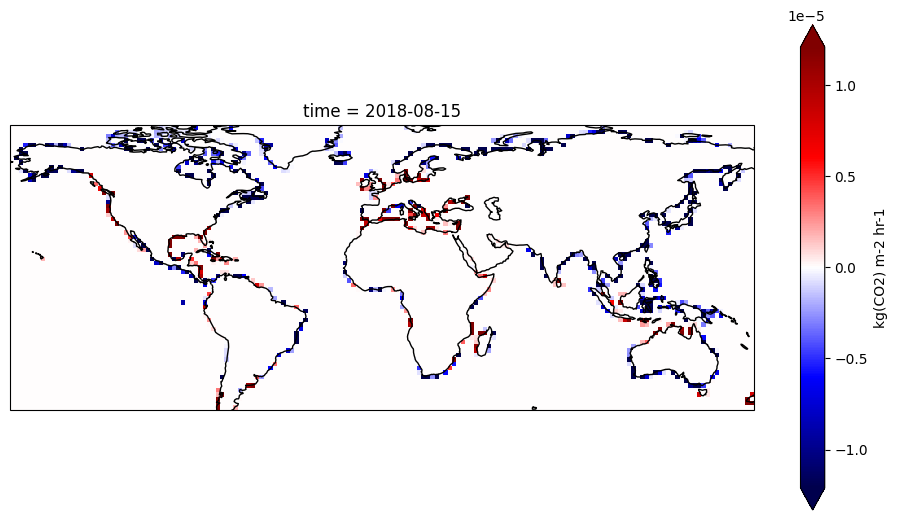

In [ ]:
dsmasked = xr.open_dataset("/home/pietaril/Documents/data/CAMS/CAMS_bio_v23r1_masked_after_interp/CAMS_v23r1_surf_CO2_bio_flux_monthly_global_2X2_2018.nc")
dsnotmasked = xr.open_dataset("/home/pietaril/Documents/data/CAMS/CAMS_bio_v23r1/CAMS_v23r1_surf_CO2_bio_flux_monthly_global_2X2_2018.nc")
t = 7
biomasked = dsmasked["flux_bio"][t,:,:]
bionotmasked = dsnotmasked["flux_bio"][t,:,:]
diff = bionotmasked - biomasked
datas = [bionotmasked, biomasked, diff]
labels = ["without mask", "with mask", "difference"]
aoi = [-170, 170, -50, 80]
diff = select_area(aoi, diff)


import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from truncate_colormap import truncate_colormap
cbar_shrink = 0.7
cbar_lab = "kg(CO2) m-2 hr-1"
cmap = mpl.colormaps["seismic"]
#cmap = truncate_colormap(mpl.colormaps["seismic"], maxval = 0.5)
suptitle="CO$_2$ bio fluxes"

fig, ax = plt.subplots(figsize = (12,9), subplot_kw=dict(projection=ccrs.PlateCarree()))

diff.plot.pcolormesh(ax=ax, robust=True, cmap=cmap,cbar_kwargs=dict(label=cbar_lab, shrink=cbar_shrink))
ax.coastlines()




In [ ]:

# fig, axs = plt.subplots(3,1, figsize = (12,9), subplot_kw=dict(projection=ccrs.PlateCarree()))
# for ind, ds in enumerate(datas):
#     ds.plot.pcolormesh(ax=axs[ind], 
#                                       robust=True, cmap=cmap,
#                                        cbar_kwargs=dict( shrink=cbar_shrink))
#     axs[ind].coastlines()

# #ax.set_title(suptitle)
# plt.tight_layout()

# Compute CAMS_bio - GFAS

In [ ]:
GFAS = "/home/pietaril/Documents/data/GFAS/GFAS_CO2_emi_preprocessed/monthly_global_2X2"
CAMSBIO = "/home/pietaril/Documents/data/CAMS/CAMS_bio_v23r1"
OUTPATH = "/home/pietaril/Documents/data/CAMS/CAMS_bio_v23r1_minus_GFAS"
varname = "flux_bio"

camsfiles = [os.path.join(CAMSBIO,f) for f in os.listdir(CAMSBIO)]
camsfiles.sort()
for file in camsfiles:
    print(file)
    year = file[-7:-3]
    print(year)
    bio = xr.open_dataset(file)
    gfasfile = [os.path.join(GFAS,f) for f in os.listdir(GFAS) if year in f]
    assert len(gfasfile) == 1
    print(gfasfile[0])
    gfas = xr.open_dataset(gfasfile[0])
    biominusfire = bio["flux_bio"] - gfas["emi_fire"]
    biominusfire.name = varname
    biominusfire.attrs = {}
    biominusfire.attrs.update({"description": "CAMS v23r1 bio CO2 monthly mean flux regridded to 2 x 2 spatial resolution. After regridding, GFAS fire emissions were subtracted from the flux",
                               "units": "kg(CO2) m-2 hr-1"})
    fname = f"CAMS_v23r1_surf_CO2_bio_flux_minus_GFAS_monthly_glob_2X2_{year}.nc"
    biominusfire.to_netcdf(os.path.join(OUTPATH,fname), encoding={'time':{'units': "days since 1900-01-01"}, varname: {'dtype': 'float64'}})
    
    

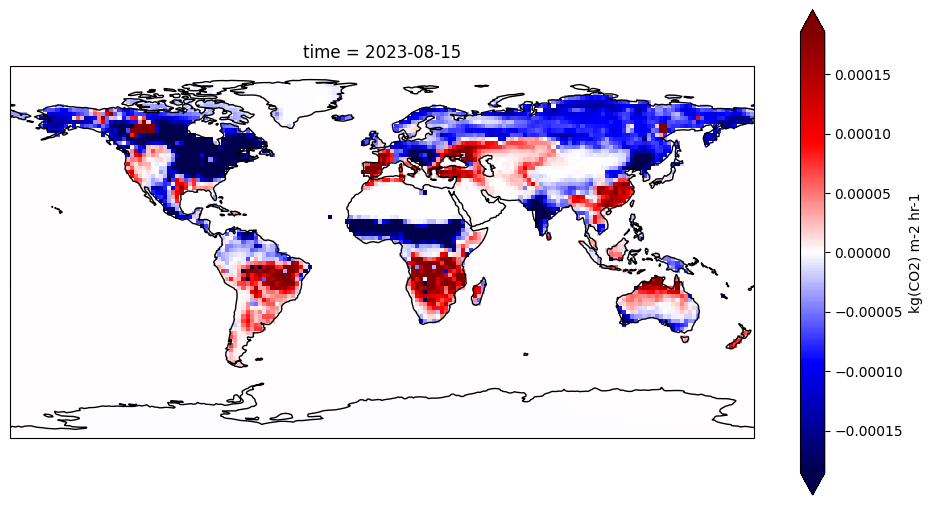

In [16]:


import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from truncate_colormap import truncate_colormap
cbar_shrink = 0.7
cbar_lab = "kg(CO2) m-2 hr-1"
cmap = mpl.colormaps["seismic"]
#cmap = truncate_colormap(mpl.colormaps["seismic"], maxval = 0.5)
suptitle="CO$_2$ bio fluxes"

fig, ax = plt.subplots(figsize = (12,9), subplot_kw=dict(projection=ccrs.PlateCarree()))

biominusfire[7,:,:].plot.pcolormesh(ax=ax, robust=True, cmap=cmap,cbar_kwargs=dict(label=cbar_lab, shrink=cbar_shrink))
ax.coastlines()

# Regrid and write to file the other sectoral CAMS for comparison

In [ ]:
#DATAPATH = "/media/pietaril/Elements/CAMS/cams73_v23r1_co2_flux_surface_mm/"
#OUTPATH = "/media/pietaril/Elements/CO2_CIF_priors/monthly/global_monthly_2X2/CAMS_ocn/"
DATAPATH = "/home/pietaril/Documents/data/CAMS/CAMS_v23r1/rawdata/cams73_v23r1_co2_flux_surface_mm"
OUTPATH = "/home/pietaril/Documents/data/CAMS/CAMS_v23r1/preprocessed_fluxes/CAMS_fos/2X2_monthly"

newlon = np.arange(-179.0, 180.0, 2)
newlat = np.arange(-89.0, 90.0, 2)
varname = "co2_fos"
identifier = "fos"


for year in range(2017,2024):
    fnames = [os.path.join(DATAPATH,f) for f in os.listdir(DATAPATH) if str(year)==f[-9:-5]]
    assert len(fnames)==12
    fnames.sort()
    ls = []
    for f in fnames:
        ds = xr.open_dataset(f)
        rename_map = {
        "flux_foss": varname
        
        }

        flx = ds.rename(rename_map)
        ds.close()
        month = f[-5:-3]
        flx = flx[varname]
        flx = flx.expand_dims({'time':pd.to_datetime([f"{year}-{month}-01"])})
        ls.append(flx)

    newds = xr.concat(ls, dim="time")

    #regrid to 2 by 2
    newds = newds.interp({'latitude':newlat, 'longitude':newlon})

    #mask landcells to zero for ocean flux
    if varname == "co2_oce":
        lsm = create_lsm_like(newds)
        newds.values[:,lsm] = 0

    #kgC per m2 per month to kgC per m2 per hr
    hours_per_month = hours_in_months(year)
    hours_per_month = hours_per_month.reshape((12,1,1))
    newds = newds/hours_per_month


    #kgC per m2 per hr to kgCO2 per m2 per hr 
    newds = newds*(44.009/12.011)

    newds.attrs = {}
    newds.attrs.update({'description': f'Global {identifier} CO2 fluxes from CAMS v23r1 in situ, regridded to 2X2 deg spatial resolution',
                        'units': 'kg(CO2) m-2 hr-1'})
    fname = f"CAMS_v23r1_surf_CO2_{identifier}_flux_monthly_global_2X2_{year}.nc"
    newds.to_netcdf(os.path.join(OUTPATH,fname), encoding={'time':{'units': "days since 1900-01-01", 'dtype':"float64"}, varname: {'dtype': 'float64'}})

In [4]:
ds = xr.open_dataset("/media/pietaril/Elements/CO2_CIF_priors/monthly/global_monthly_2X2/CAMS_bio_v23r1/CAMS_v23r1_surf_CO2_bio_flux_monthly_global_2X2_2018.nc")
ds

<xarray.Dataset>
Dimensions:    (time: 12, latitude: 90, longitude: 180)
Coordinates:
  * time       (time) datetime64[ns] 2018-01-15 2018-02-15 ... 2018-12-15
  * latitude   (latitude) float64 -89.0 -87.0 -85.0 -83.0 ... 85.0 87.0 89.0
  * longitude  (longitude) float64 -179.0 -177.0 -175.0 ... 175.0 177.0 179.0
Data variables:
    flux_bio   (time, latitude, longitude) float64 ...

# Regrid and write to file the "total" CAMS

In [7]:
from dask.distributed import Client
client = Client(n_workers=os.cpu_count()-2, threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 6
Total threads: 6,Total memory: 30.76 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45719,Workers: 6
Dashboard: http://127.0.0.1:8787/status,Total threads: 6
Started: Just now,Total memory: 30.76 GiB
Comm: tcp://127.0.0.1:43673,Total threads: 1
Dashboard: http://127.0.0.1:43151/status,Memory: 5.13 GiB
Nanny: tcp://127.0.0.1:34183,


In [8]:
ds

<xarray.Dataset>
Dimensions:    (longitude: 360, latitude: 180, time: 2920)
Coordinates:
  * longitude  (longitude) float64 -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
  * latitude   (latitude) float64 -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * time       (time) datetime64[ns] 2017-01-01 ... 2017-12-31T21:00:00
Data variables:
    lsf        (time, latitude, longitude) float64 dask.array<chunksize=(248, 180, 360), meta=np.ndarray>
    area       (time, latitude, longitude) float64 dask.array<chunksize=(248, 180, 360), meta=np.ndarray>
    flux_apri  (time, latitude, longitude) float64 dask.array<chunksize=(248, 180, 360), meta=np.ndarray>
    flux_apos  (time, latitude, longitude) float64 dask.array<chunksize=(248, 180, 360), meta=np.ndarray>
    flux_foss  (time, latitude, longitude) float64 dask.array<chunksize=(248, 180, 360), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    title:        Global surface fluxes inferred by atmospheric inversion
    institution:  LSCE (CEA/CNRS/UVSQ) - IPSL
    source:       Assimilation of surface air-sample measurements
    note:         the flux fields have been interpolated from the native hexa...
    history:      2024-08-28 10:10:28 GMT, PYVAR run by p24cheva
    references:   doi:10.1029/2005JD006390, doi:10.5194/gmd-6-783-2013, doi:1...
    comment:      Positive fluxes release carbon to the atmosphere

In [13]:
OUTPATH = "/home/pietaril/Documents/data/CAMS/CAMS_tot" #"/media/pietaril/Elements/CO2_CIF_priors/monthly/global_monthly_2X2/CAMS_v23r1_not_sectoral/"
CAMSPATH= "/home/pietaril/Documents/data/CAMS/cams73_v23r1_co2_flux_surface_inst" #"/media/pietaril/Elements/CAMS/cams73_v23r1_co2_flux_surface_inst/"

newlon = np.arange(-179.0, 180.0, 2)
newlat = np.arange(-89.0, 90.0, 2)
varname = "co2_net"

for year in range(2017,2018):
    fnames_yearly = [os.path.join(CAMSPATH, f) for f in os.listdir(CAMSPATH) if f[-9:-5]==str(year)]
    assert len(fnames_yearly)==12
    ds = xr.open_mfdataset(fnames_yearly)
    assert ds.time.dt.year[0] == year
    rename_map = {
        "flux_apos": varname
        
        }
    flx = ds.rename(rename_map)
    ds.close()
    flx = flx[varname]
    flx = flx.interp({'latitude':newlat, 'longitude':newlon})
    #downsample to monthly time resolution
    flx = flx.resample(time="1MS").mean(skipna=True)

    #unit conversion kgC m-2 s-1 to kg CO2 m-2 hr-1
    flx = flx*(44.009/12.011)*3600

    flx.attrs.update({'description': 'CO2 posterior fluxes from surface air-sample optimized CAMS v23r1, regridded to 2X2 deg spatial, monthly temporal resolution',
                        'units': 'kg(CO2) m-2 hr-1'})
    fname = f"CAMS_v23r1_surf_CO2_flux_monthly_global_2X2_{year}.nc"
    flx.to_netcdf(os.path.join(OUTPATH,fname), encoding={'time':{'units': "days since 1900-01-01", 'dtype':'float64'}, varname:{'dtype':'float64'}})

    


In [15]:
ds = xr.open_dataset("/home/pietaril/Documents/data/CAMS/CAMS_tot/CAMS_v23r1_surf_CO2_flux_monthly_global_2X2_2018.nc")
ds

<xarray.Dataset>
Dimensions:    (latitude: 90, longitude: 180, time: 12)
Coordinates:
  * latitude   (latitude) float64 -89.0 -87.0 -85.0 -83.0 ... 85.0 87.0 89.0
  * longitude  (longitude) float64 -179.0 -177.0 -175.0 ... 175.0 177.0 179.0
  * time       (time) datetime64[ns] 2018-01-01 2018-02-01 ... 2018-12-01
Data variables:
    co2_net    (time, latitude, longitude) float64 ...

# Compare different ways to compute the total monthly flux

In [3]:


JENAPATH = "/media/pietaril/Elements/CO2_CIF_priors/monthly/global_monthly_2X2/JenaCarboScope/"
GFASPATH = "/media/pietaril/Elements/CO2_CIF_priors/monthly/global_monthly_2X2/GFAS/"
EDGARPATH = "/media/pietaril/Elements/CO2_CIF_priors/monthly/global_monthly_2X2/EDGAR2024_CO2/"
BIOPATH = "/media/pietaril/Elements/CO2_CIF_priors/monthly/global_monthly_2X2/CAMS_bio_v23r1"





    

In [29]:
folders = [JENAPATH,GFASPATH, EDGARPATH, BIOPATH]

# Target years
years = list(range(2018, 2024))
if len(folders)==4:
    TOTPATH = "/media/pietaril/Elements/CO2_CIF_priors/monthly/global_monthly_2X2/jena+gfas+edgar+camsbio/"
    description = "Jena + GFAS + EDGAR + CAMS BIO"
    identifier = "with"
elif len(folders)==3:
    TOTPATH = "/media/pietaril/Elements/CO2_CIF_priors/monthly/global_monthly_2X2/jena+edgar+camsbio/"
    description = "Jena + EDGAR + CAMS BIO"
    identifier = "without"

else:
    raise ValueError("Wrong number of folders")

for year in years:
    yearly_datasets = []

    for folder in folders:
        for fname in os.listdir(folder):
            if str(year) in fname and fname.endswith(".nc"):
                fpath = os.path.join(folder, fname)
                ds = xr.open_dataset(fpath)
                assert ds.time.dt.year[0] == year
                # Assume only one variable per dataset
                varname = list(ds.data_vars.keys())[0]
                var = ds[varname]

                # Add to list
                yearly_datasets.append(var)

    
 
    assert len(yearly_datasets)==len(folders)
    summed = sum(yearly_datasets)
    summed.name = "tot_flux"
    summed.attrs.update({'description': description})
    summed.to_netcdf(os.path.join(TOTPATH, f"sum_{identifier}_gfas_{year}.nc"), encoding={'time':{'units': "days since 1900-01-01"}})


In [38]:
CAMSBIO = "/media/pietaril/Elements/CO2_CIF_priors/monthly/global_monthly_2X2/CAMS_bio_v23r1"
CAMSFOSS = "/media/pietaril/Elements/CO2_CIF_priors/monthly/global_monthly_2X2/CAMS_ocean+CAMS_bio+CAMS_foss/CAMS_foss"
CAMSOCEAN = "/media/pietaril/Elements/CO2_CIF_priors/monthly/global_monthly_2X2/CAMS_ocean+CAMS_bio+CAMS_foss/CAMS_ocean"


folders = [CAMSBIO, CAMSFOSS, CAMSOCEAN]

# Target years
years = list(range(2018, 2024))


TOTPATH = "/media/pietaril/Elements/CO2_CIF_priors/monthly/global_monthly_2X2/CAMS_ocean+CAMS_bio+CAMS_foss"
description = "CAMSbio + CAMSocean + CAMSfoss"



for year in years:
    yearly_datasets = []

    for folder in folders:
        for fname in os.listdir(folder):
            if str(year) in fname and fname.endswith(".nc"):
                fpath = os.path.join(folder, fname)
                ds = xr.open_dataset(fpath)
                assert ds.time.dt.year[0] == year
                # Assume only one variable per dataset
                varname = list(ds.data_vars.keys())[0]
                var = ds[varname]

                # Add to list
                yearly_datasets.append(var)

    
 
    assert len(yearly_datasets)==len(folders)
    summed = sum(yearly_datasets)
    summed.name = "tot_flux"
    summed.attrs.update({'description': description})
    summed.to_netcdf(os.path.join(TOTPATH, f"sum_{description}_{year}.nc"), encoding={'time':{'units': "days since 1900-01-01"}})

In [ ]:
CAMS = "/media/pietaril/Elements/CO2_CIF_priors/monthly/global_monthly_2X2/CAMS_v23r1_total/"
NOGFAS = "/media/pietaril/Elements/CO2_CIF_priors/monthly/global_monthly_2X2/jena+edgar+camsbio/"
WITHGFAS = "/media/pietaril/Elements/CO2_CIF_priors/monthly/global_monthly_2X2/jena+gfas+edgar+camsbio/"


def get_datasets(year):
    datasets_year = []
    for folder in [CAMS, NOGFAS, WITHGFAS]:
        for fname in os.listdir(folder):
            if str(year) in fname and fname.endswith(".nc"):
                fpath = os.path.join(folder,fname)
                ds = xr.open_dataset(fpath)
                assert ds.time.dt.year[0] == year
                datasets_year.append(ds)
    assert len(datasets_year) == 3

    return datasets_year#datasets_year[0], datasets_year[1], datasets_year[2]


cams, nogfas, withgfas = get_datasets(2019)

#cams, ngfas, wgfas = get_datasets(2018)


In [10]:
ds = xr.open_dataset("/media/pietaril/Elements/CO2_CIF_priors/monthly/global_monthly_2X2/CAMS_v23r1_not_sectoral/CAMS_v23r1_surf_CO2_flux_monthly_global_2X2_2018.nc")
ds

<xarray.Dataset>
Dimensions:    (latitude: 90, longitude: 180, time: 12)
Coordinates:
  * latitude   (latitude) float64 -89.0 -87.0 -85.0 -83.0 ... 85.0 87.0 89.0
  * longitude  (longitude) float64 -179.0 -177.0 -175.0 ... 175.0 177.0 179.0
  * time       (time) datetime64[ns] 2018-01-15 2018-02-15 ... 2018-12-15
Data variables:
    flux_tot   (time, latitude, longitude) float64 ...

In [4]:


def monthly_fluxes_to_Tg_per_yr(ds):
    from areagrid import areagrid
    #ensure that time axis in ascending order
    ds = ds.sortby("time")
    #pick the first time stamp to be the time coordinate representing the whole year
    time = ds["time"].values[0]

    
    #compute how many hours in each month of the year
    year = ds["time"].dt.year.values[0]
    hours_per_month = hours_in_months(year)
    hours_per_month = hours_per_month.reshape((12,1,1))

    #multiply the monthly gridmaps by hours per month to get unit kg/m2/month_i for each month
    out = hours_per_month *ds

    #sum the monthly gridmaps to get one map with unit kg/m2/yr
    out = out.sum(dim="time")

    areas = areagrid(out.latitude.values, out.longitude.values)
    out = out*areas
    out = out.sum(dim=("latitude", "longitude"))

    #kg to Tg
    out *= 1e-9 


    #out = out.to_dataset()

    out.coords["time"] = (time) 
    out = out.expand_dims("time")
    return out

In [5]:
#CAMS = "/media/pietaril/Elements/CO2_CIF_priors/monthly/global_monthly_2X2/CAMS_v23r1_not_sectoral/"
#NOGFAS = "/media/pietaril/Elements/CO2_CIF_priors/monthly/global_monthly_2X2/jena+edgar+camsbio/"
#WITHGFAS = "/media/pietaril/Elements/CO2_CIF_priors/monthly/global_monthly_2X2/jena+gfas+edgar+camsbio/"
#CAMSSECTORSUM = "/media/pietaril/Elements/CO2_CIF_priors/monthly/global_monthly_2X2/CAMS_ocean+CAMS_bio+CAMS_foss"

#CAMSMINUSGFAS = "/home/pietaril/Documents/data/CAMS/CAMS_bio_v23r1_minus_GFAS"
CAMSBIO = "/home/pietaril/Documents/data/CAMS/CAMS_v23r1/preprocessed_fluxes/CAMS_bio/2X2_monthly"
#CAMSTOT = "/home/pietaril/Documents/data/CAMS/CAMS_tot"
JSBACH = "/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_global_202506/global_2X2_monthly"
GFAS = "/home/pietaril/Documents/data/GFAS/GFAS_CO2_emi_preprocessed/monthly_global_2X2"
GFED = "/home/pietaril/Documents/data/GFED4.1s/2X2_monthly"

def collect_yearly_totals(PATH):
    
    fnames = [os.path.join(PATH, f) for f in os.listdir(PATH)]
    datasets = [xr.open_dataset(fname) for fname in fnames if fname.endswith(".nc")]

    yearly_fluxes = []
    for ds in datasets:
        yearly_flux = monthly_fluxes_to_Tg_per_yr(ds)
        #print(yearly_flux.values)
        yearly_fluxes.append(yearly_flux)

    ds_allyears = xr.concat(yearly_fluxes, dim="time") 
    ds_allyears = ds_allyears.sortby("time")
    return ds_allyears



#cams_tots = collect_yearly_totals(CAMSTOT)
#nogfas = collect_yearly_totals(NOGFAS)
#withgfas = collect_yearly_totals(WITHGFAS)
#camssectorsum = collect_yearly_totals(CAMSSECTORSUM)
camsbio = collect_yearly_totals(CAMSBIO)
#camsbiominusgfas = collect_yearly_totals(CAMSMINUSGFAS)
jsbach = collect_yearly_totals(JSBACH)
#camsfoss = collect_yearly_totals(CAMSFOSS)
#camsocn = collect_yearly_totals(CAMSOCEAN)
#jena = collect_yearly_totals(JENAPATH)
#edgar = collect_yearly_totals(EDGARPATH)
gfas = collect_yearly_totals(GFAS) 
gfed = collect_yearly_totals(GFED)

In [24]:
gfas

<xarray.Dataset>
Dimensions:   (time: 11)
Coordinates:
  * time      (time) datetime64[ns] 2013-01-15 2014-01-15 ... 2023-01-15
Data variables:
    emi_fire  (time) float64 5.774e+03 6.498e+03 ... 4.955e+03 7.072e+03

In [23]:
gfed

<xarray.Dataset>
Dimensions:   (time: 7)
Coordinates:
  * time      (time) datetime64[ns] 2017-01-01 2018-01-01 ... 2023-01-01
Data variables:
    co2_fire  (time) float64 6.272e+03 6.09e+03 ... 5.642e+03 7.992e+03

In [7]:
import matplotlib.pyplot as plt


ds_tots = xr.Dataset()
#ds_tots["cams"] = cams_tots["flux_tot"]
#ds_tots["jena+edgar+camsbio"] = nogfas["tot_flux"]
#ds_tots["jena+edgar+gfas+camsbio"] = withgfas["tot_flux"]
#ds_tots["camsbio+camsfoss+camsocn"] = camssectorsum["tot_flux"]
ds_tots["camsbio"] = camsbio["co2_bio"]
#ds_tots["camsbiominusgfas"] = camsbiominusgfas["flux_bio"]
#ds_tots["camstot"] = cams_tots["flux_tot"]
ds_tots["jsbach"] = jsbach["nee"]
#ds_tots["camsfoss"]=camsfoss["emi_foss"]
#ds_tots["edgar"] = edgar["emi_anth"]
#ds_tots["camsocn"] = camsocn["emi_ocean"]
#ds_tots["jenaocn"] = jena["emi_ocn"]
ds_tots["gfas"] = gfas["co2_fire"]
ds_tots["gfed"] = gfed["co2_fire"]

In [8]:
ds_tots

<xarray.Dataset>
Dimensions:  (time: 7)
Coordinates:
  * time     (time) datetime64[ns] 2017-01-01 2018-01-01 ... 2023-01-01
Data variables:
    camsbio  (time) float64 -1.046e+04 -1.035e+04 ... -1.037e+04 -1.832e+03
    jsbach   (time) float64 -3.886e+03 -5.641e+03 ... -1.054e+04 -1.35e+03
    gfas     (time) float64 5.188e+03 5.325e+03 ... 4.955e+03 7.072e+03
    gfed     (time) float64 6.272e+03 6.09e+03 7.436e+03 ... 5.642e+03 7.992e+03

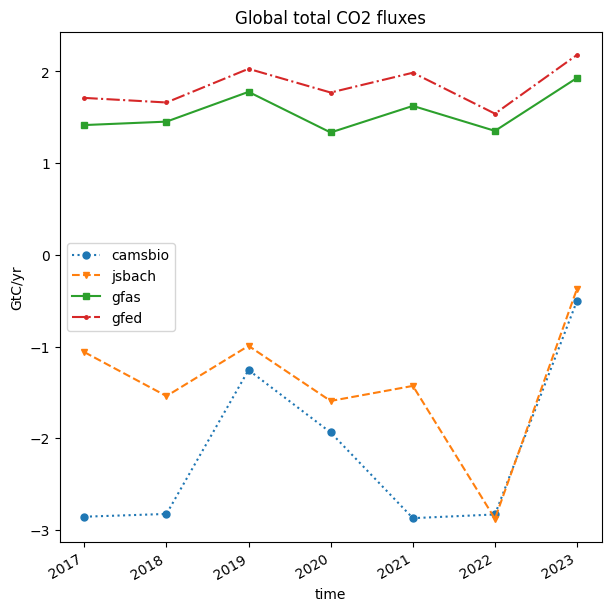

In [9]:



fig, ax = plt.subplots(layout="constrained", figsize=(6,6))#, figsize=(9,6))

vars = list(ds_tots.data_vars.keys())
#labels = ["CAMS", "CAMS bio + EDGAR + JenaCarboScope", "CAMS bio + EDGAR + JenaCarboScope + GFAS", "CAMS_bio + CAMS_ocn + CAMS_fossile"]
linestyles = ["dotted", "dashed", "solid", "dashdot"]
linestyles = linestyles*3
markers = ['o', 'v', 's', ".", "D"]

markers = markers*3

for (ind,var) in enumerate(vars):
    # convert to gigatonnes of C
    data = ds_tots[var]*(12.011/44.009)*1e-3
    data.plot(x="time", ax=ax, marker= markers[ind], linestyle=linestyles[ind], markersize=5,  label=var)
ax.set_ylabel("GtC/yr") #markerfacecolor='white',
ax.set_title("Global total CO2 fluxes")
plt.legend()
# Shrink current axis's height by 10% on the bottom
#box = ax.get_position()
#ax.set_position([box.x0, box.y0 + box.height * 0.1,
#                 box.width, box.height * 0.9])

# Put a legend below current axis
#ax.legend(loc='upper center', bbox_to_anchor=(0.5, 0.4),
#        ncol=2)

In [70]:
ds_tots["camsbio"]*(12.011/44.009)*1e-3

<xarray.DataArray 'camsbio' (time: 7)>
array([-2.93145464, -2.90687938, -1.26724317, -1.97432135, -2.97309681,
       -2.90257565, -0.50612956])
Coordinates:
  * time     (time) datetime64[ns] 2017-01-15 2018-01-15 ... 2023-01-15